In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Q1
We need pandas, numpy and matplotlib for this assignnment

### Q2

In [10]:
df = pd.read_csv(r"bhatbhateni_sales.csv")

### Q3a

In [11]:
df.head()

,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,TXN101590,2025-05-19,CUST1100,Sujan Shrestha,Pokhara - Lakeside,Bakery,Chocolate Cake Slice,2,171.29,342.58,Khalti
1,TXN103282,2025-03-07,CUST1005,Milan Lama,Butwal - Traffic Chowk,Personal Care,Dove Soap,3,149.59,448.77,eSewa
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,2794.25,11177.00,Khalti
3,TXN102479,2025-11-12,CUST1057,Neha Karki,Kathmandu - New Road,Household,Surf Excel 1kg,4,399.62,1598.48,Cash
4,TXN104408,2025-10-09,CUST1005,Milan Lama,Butwal - Traffic Chowk,Beverages,Gorkha Beer (6-pack),2,281.01,562.02,eSewa


In [12]:
#Q3b
df.size

206932

In [13]:
# Q3c
df.columns

Index(['TransactionID', 'Date', 'CustomerID', 'CustomerName', 'Branch',
       'ProductCategory', 'ProductName', 'Quantity', 'UnitPrice',
       'TotalAmount', 'PaymentMethod'],
      dtype='str')

### Step 4

In [14]:
# 4a
df.dtypes

TransactionID          str
Date                   str
CustomerID             str
CustomerName           str
Branch                 str
ProductCategory        str
ProductName            str
Quantity             int64
UnitPrice          float64
TotalAmount        float64
PaymentMethod          str
dtype: object

In [15]:
# q4b
df.describe()

,Quantity,UnitPrice,TotalAmount
count,18812.000000,18441.000000,18812.000000
mean,2.506804,728.803530,1819.990565
std,1.114328,766.346109,2241.968350
min,1.000000,40.140000,40.610000
25%,2.000000,240.160000,488.397500
50%,3.000000,416.780000,989.000000
75%,3.000000,848.320000,2142.545000
max,4.000000,3499.280000,13997.120000


### step 5

In [16]:
#q5a
missing_precent = len(df.isna())/df.size

In [17]:
# q5b
len(df[df.duplicated()])

724

In [18]:
#q5c
df.nunique().sum()

np.int64(40385)

In [19]:
# q5d
total = df["Quantity"] * df["UnitPrice"] #calculating total amount


In [20]:
len(df[df["TotalAmount"] != total]) #finding count


1821

### step 6

In [21]:
# 6a

df.drop_duplicates(inplace = True) # remove dupl

In [22]:
# 6b
df.duplicated().sum() # check if duplicates are removed

np.int64(0)

### Step 7

In [23]:
#q7a
df['CustomerName'] = df['CustomerName'].fillna('Unknown Customer')

In [24]:
#q7b


name_to_cat = (df.dropna(subset=['ProductCategory'])
                 .groupby('ProductName')['ProductCategory']#mapping using mode of not na data
                 .agg(lambda x: x.mode()[0]))


In [25]:
df['ProductCategory'] = df['ProductCategory'].fillna(df['ProductName'].map(name_to_cat))


In [26]:
# q7c
df["UnitPrice"] = df["UnitPrice"].fillna(df["TotalAmount"]/df["Quantity"]) #fill na using totalamount/quantity


In [27]:
# q7d
df['PaymentMethod'] = df['PaymentMethod'].fillna('Unknown')
# flag as uknown because it is not justfifiable to drop a whole datapoint for a missing payment method
# other columns are still valid and can be used for analysis

In [28]:
df.isna().sum()

TransactionID      0
Date               0
CustomerID         0
CustomerName       0
Branch             0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
dtype: int64

In [29]:
# Q7e. Confirm no remaining missing values
df.isnull().sum()

TransactionID      0
Date               0
CustomerID         0
CustomerName       0
Branch             0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
dtype: int64

### Step 8 


In [30]:
#q8a

df["Date"] = pd.to_datetime(df["Date"])

df["Date"].dt.year.value_counts()

Date
2025    18088
Name: count, dtype: int64

In [31]:
# q8b
df["City"] = df["Branch"].str.split("-").str[-1].str.strip() #split "-" using str 

In [32]:
# q8c
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"] #recalculate total amount after imputation

### Step 9 

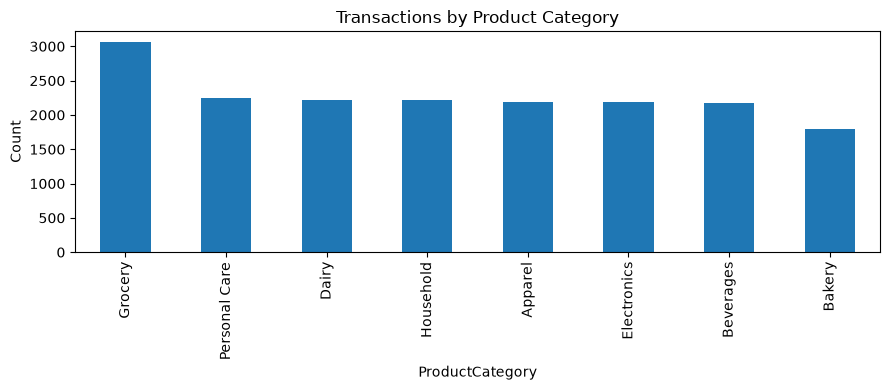

In [34]:
#q9a 
df['ProductCategory'].value_counts().plot(kind='bar', figsize=(9,4), title='Transactions by Product Category')
plt.ylabel('Count'); plt.tight_layout(); plt.show()


In [ ]:
# Q9b
df['Branch'].value_counts()


Branch
Kathmandu - Kupondole       3241
Bhaktapur - Suryabinayak    3050
Butwal - Traffic Chowk      2940
Kathmandu - New Road        2561
Lalitpur - Pulchowk         2337
Pokhara - Lakeside          1957
Chitwan - Bharatpur         1063
Biratnagar - Main Road       939
Name: count, dtype: int64

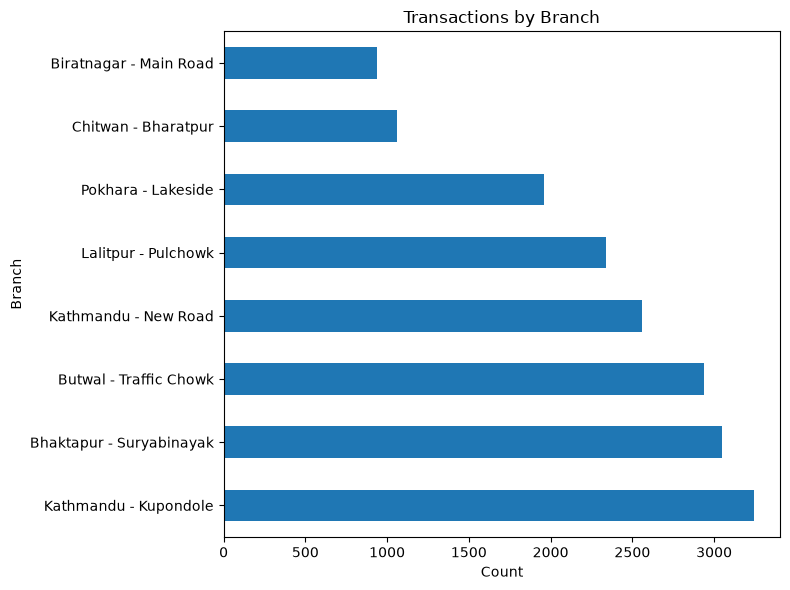

In [36]:
df['Branch'].value_counts().plot(kind='barh', figsize=(8,6), title='Transactions by Branch')
plt.xlabel('Count'); plt.tight_layout(); plt.show()


In [37]:
# Q9c
df['PaymentMethod'].value_counts()

PaymentMethod
Cash                 6218
eSewa                4951
Khalti               3795
Debit/Credit Card    1813
Bank Transfer         859
Unknown               452
Name: count, dtype: int64

Skew: 2.4642570960145753


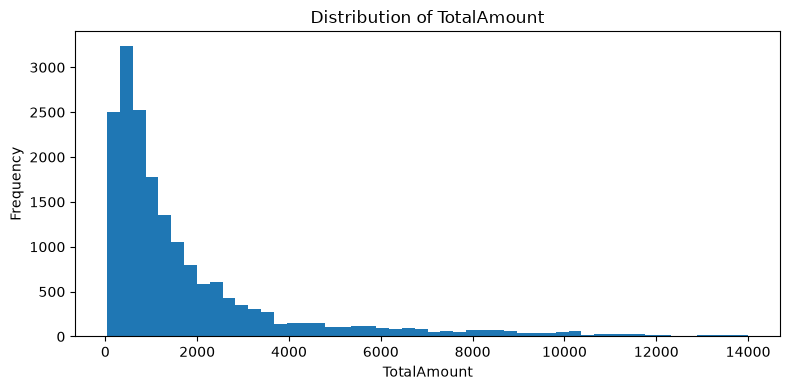

In [38]:
# Q9
print('Skew:', df['TotalAmount'].skew())
df['TotalAmount'].plot(kind='hist', bins=50, figsize=(8,4), title='Distribution of TotalAmount')
plt.xlabel('TotalAmount'); plt.tight_layout(); plt.show()


### Question 10

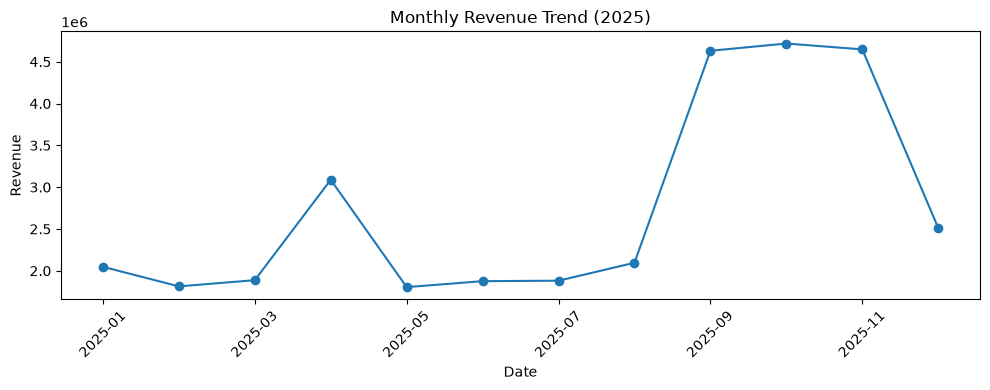

In [39]:
# Q10a
monthly = df.groupby(df['Date'].dt.to_period('M'))['TotalAmount'].sum()
monthly.index = monthly.index.astype(str)
monthly.plot(kind='line', marker='o', figsize=(10,4), title='Monthly Revenue Trend (2025)')
plt.ylabel('Revenue'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [41]:
# Q10b
df['IsWeekend'] = df['Date'].dt.dayofweek >= 5
df.groupby('IsWeekend')['TotalAmount'].sum().rename({True: 'Weekend', False: 'Weekday'})


IsWeekend
Weekday    23705495.89
Weekend     9298649.75
Name: TotalAmount, dtype: float64

In [43]:
# Q10c
df['DayOfWeek'] = df['Date'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)


DayOfWeek
Monday       4826070.64
Tuesday      4836536.99
Wednesday    4874642.96
Thursday     4876393.65
Friday       4291851.65
Saturday     4474756.59
Sunday       4823893.16
Name: TotalAmount, dtype: float64

### step 12


In [44]:
# Q12a
cat_summary = df.groupby('ProductCategory').agg(
    total_revenue=('TotalAmount', 'sum'),
    transactions=('TransactionID', 'count')
).sort_values('total_revenue', ascending=False)
cat_summary

,total_revenue,transactions
ProductCategory,,
Electronics,10419134.62,2186
Apparel,9251535.64,2188
Grocery,3943021.00,3065
Household,3620342.47,2212
Personal Care,2064900.31,2246
Beverages,1558152.52,2179
Dairy,1260518.61,2217
Bakery,886540.47,1795


In [45]:
# Q12b
df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)


ProductName
Wall Clock            1215
Dove Soap             1194
Coca-Cola 1.5L        1183
Sliced Bread          1174
Extension Board       1167
Sanitary Pads Pack    1163
Paneer 250g           1163
Mustard Oil 1L        1157
LED Bulb 9W           1150
DDC Milk 1L           1146
Name: Quantity, dtype: int64

In [46]:
# Q12c
df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)


ProductName
Wall Clock             2459453.52
Extension Board        2155259.21
Power Bank 10000mAh    1977709.90
USB Cable Type-C       1968887.55
Kids Frock             1928877.20
Bluetooth Earphones    1857824.44
Socks (3-pair pack)    1855597.09
Cotton T-Shirt         1854507.38
Winter Jacket          1842626.06
Formal Shirt           1769927.91
Name: TotalAmount, dtype: float64

### Step 13

In [47]:
# Q13a
df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(10)


CustomerName
Kritika Bhattarai    1210202.18
Alina Rai            1170925.25
Unknown Customer     1064651.27
Alina Shrestha       1063044.88
Kiran Poudel         1058165.81
Bikash Shrestha      1053659.23
Aashish Poudel       1045754.25
Neha Karki           1043193.73
Sarita Poudel         928717.65
Sujan Shrestha        887527.87
Name: TotalAmount, dtype: float64

In [48]:
# Q13b
order_counts = df.groupby('CustomerID')['TransactionID'].nunique()
repeat = (order_counts > 1).sum()
one_time = (order_counts == 1).sum()
print('Repeat customers:', repeat)
print('One-time customers:', one_time)


Repeat customers: 144
One-time customers: 3


In [49]:
# Q13c
df.groupby('CustomerID')['TotalAmount'].sum().mean()


np.float64(224517.99755102038)

### step 14


In [50]:
# q14
pd.crosstab(df['Branch'], df['PaymentMethod'], normalize='index').round(2)


PaymentMethod,Bank Transfer,Cash,Debit/Credit Card,Khalti,Unknown,eSewa
Branch,,,,,,
Bhaktapur - Suryabinayak,0.05,0.35,0.11,0.21,0.02,0.27
Biratnagar - Main Road,0.05,0.33,0.09,0.22,0.02,0.28
Butwal - Traffic Chowk,0.05,0.36,0.09,0.20,0.02,0.27
Chitwan - Bharatpur,0.05,0.33,0.09,0.23,0.02,0.28
Kathmandu - Kupondole,0.05,0.33,0.10,0.22,0.03,0.27
Kathmandu - New Road,0.05,0.36,0.09,0.21,0.03,0.26
Lalitpur - Pulchowk,0.05,0.34,0.11,0.20,0.03,0.27
Pokhara - Lakeside,0.04,0.33,0.10,0.21,0.02,0.29


In [51]:
# Q14b
df.groupby('PaymentMethod')['TotalAmount'].mean().sort_values(ascending=False)


PaymentMethod
Unknown              1918.796571
Khalti               1881.365852
Bank Transfer        1849.672328
Debit/Credit Card    1819.482477
eSewa                1815.580287
Cash                 1788.442895
Name: TotalAmount, dtype: float64

### Step 15

In [52]:
# Q15
df[['Quantity', 'UnitPrice', 'TotalAmount']].corr()


,Quantity,UnitPrice,TotalAmount
Quantity,1.000000,-0.005469,0.360532
UnitPrice,-0.005469,1.000000,0.848195
TotalAmount,0.360532,0.848195,1.000000


In [53]:
# Q15b
Q1 = df['TotalAmount'].quantile(0.25)
Q3 = df['TotalAmount'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['TotalAmount'] < lower) | (df['TotalAmount'] > upper)]
print('Outlier transactions:', len(outliers))
print(f'Bounds: [{lower:.2f}, {upper:.2f}]')


Outlier transactions: 1763
Bounds: [-2007.41, 4648.61]
